# Trabajo Práctico TS1

Se sintetizan distintas señales discretas y se analizan sus propiedades.

Se define:
- Frecuencia de muestreo: fs = 40 kHz
- Tiempo entre muestras: ts = 1/fs
- Número de muestras: n = 200

Esto permite representar correctamente señales en el rango de interés.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../lib')

from mis_funciones import mi_senoidal

## Parámetros generales

Se fijan los parámetros de muestreo y de la señal.

In [2]:
fs = 40000
f0 = 2000
n = 200
vmax = 1
dc = 0
ts = 1/fs

## Señal senoidal de 2 kHz

Se genera una señal senoidal de amplitud 1 V.

La potencia de una senoidal es:
P = A^2 / 2

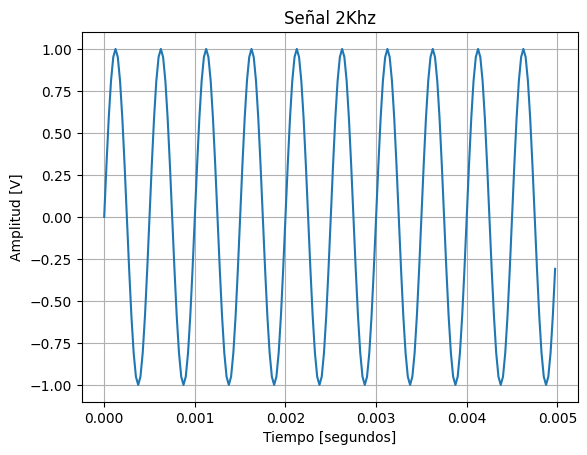

In [4]:
P = (vmax**2)/2

tt, xx = mi_senoidal(vmax, dc, f0, n, fs, ts, ph=0)

plt.figure(1)
plt.title('Señal 2Khz')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx)
plt.grid()
plt.show()

## Señal amplificada y desfasada

Se amplifica la señal por un factor k = 2 y se aplica un desfase de π/2.

La potencia escala cuadráticamente con la amplitud.

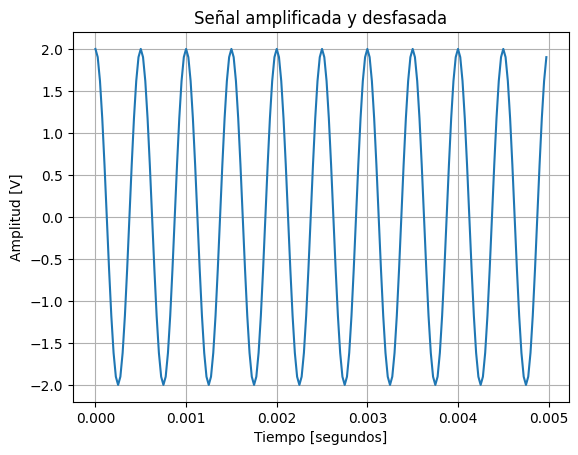

In [5]:
k = 2 #Factor de amplificacion
P = ((k * vmax)**2)/2 # La potencia escala al cuadrado

tt, xx = mi_senoidal(k * vmax, dc, f0, n, fs, ts, ph=np.pi/2)

plt.figure(2)
plt.title('Señal amplificada y desfasada')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx)
plt.grid()
plt.show()

## 3. Modulación en amplitud

Se modula la señal con otra senoidal de frecuencia f0/2:

x[n] = (1 + m cos(2π (f0/2) n ts)) cos(2π f0 n ts)

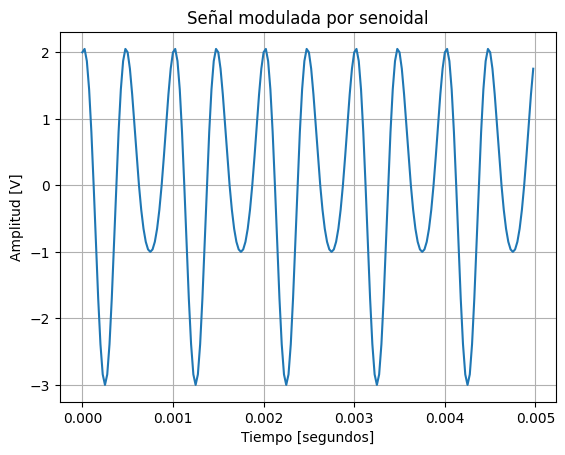

In [6]:
m = 0.5 #factor de modulación

tt, xxm = mi_senoidal(vmax, dc, f0/2, n, fs, ts, ph=0) #Senoidal moduladora
xx_mod = xx * ( 1 + m * xxm)

plt.figure(3)
plt.title('Señal modulada por senoidal')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx_mod)
plt.grid()
plt.show()


## 4. Señal recortada al 75%

Se aplica un recorte (clipping) limitando la amplitud máxima al 75%.

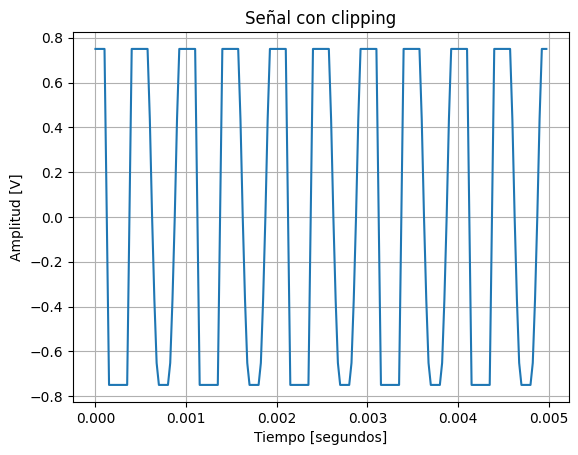

In [7]:
a_lim = 0.75

xx_clip = np.copy(xx_mod)

xx_clip[xx_clip > a_lim] = a_lim
xx_clip[xx_clip < -a_lim] = -a_lim

plt.figure(4)
plt.title('Señal con clipping')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx_clip)
plt.grid()
plt.show()

## 5. Señal cuadrada de 4 kHz

Se genera una señal cuadrada a partir del signo de una señal senoidal.

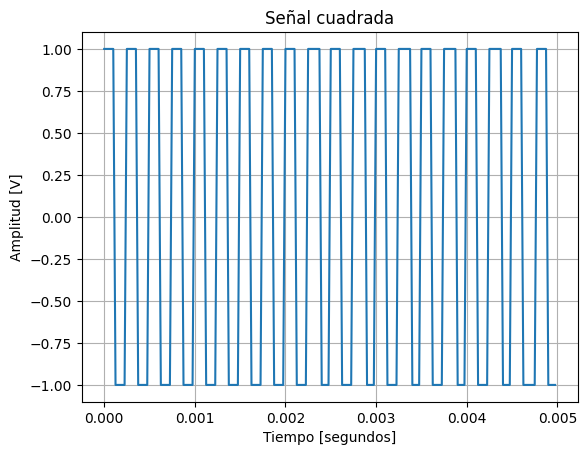

In [8]:
from scipy import signal

f0c = 4000 #Frecuencia de onda cuadrada 4KHz

tt = np.linspace(0, (n-1)/fs, n)
xx_sq = signal.square(2*np.pi*f0c*tt)

plt.figure(5)
plt.title('Señal cuadrada')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx_sq)
plt.grid()
plt.show()

## 6. Pulso rectangular de 10 ms

Se genera un pulso activo durante 10 ms.

La energía de la señal se calcula como:

E = Σ |x[n]|²

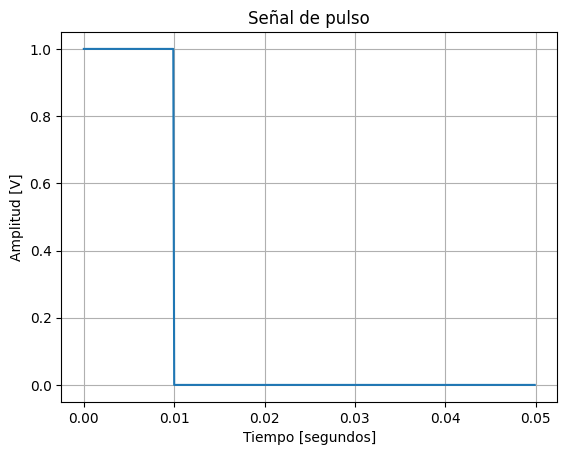

In [9]:
fs = 10000
ts = 1/fs

t_total = 0.05  # 50 ms
n = int(t_total * fs)

tt = np.linspace(0, (n-1)*ts, n)

T = 0.01  # 10 ms
A = 1

xx = np.zeros(n)
xx = A * (tt < T)

plt.figure(6)
plt.title('Señal de pulso')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, xx)
plt.grid()
plt.show()

# Ejercicio 2 - Convolución

Se tiene el sistema:

h[n] = δ[n] - δ[n-4]

Esto representa un sistema que resta una versión retardada de la señal:

y[n] = x[n] - x[n-4]

In [11]:
from IPython.display import IFrame
IFrame("TS1.pdf", width=700, height=500)

## Validación numérica

Se verificó mediante simulación que la convolución con h[n] = δ[n] - δ[n-4] equivale a:

y[n] = x[n] - x[n-4]

Los resultados obtenidos numéricamente coinciden con los cálculos analíticos realizados en papel para los tres casos.

In [3]:
#%% Chequeo de ejercicios de convolución

from scipy import signal as sig

# Eje temporal
n = np.arange(-10, 20)

# Respuesta al impulso
h = np.zeros_like(n)
h[n == 0] = 1
h[n == 4] = -1

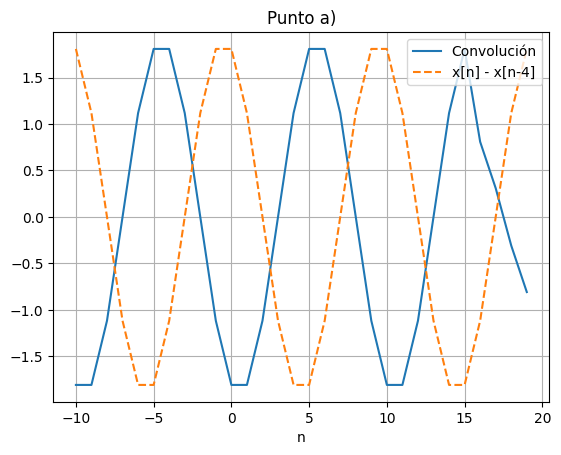

In [4]:
#%% A) x(n) = cos(w0*n*Ts)
# Parámetros
w0 = 0.2 * np.pi
Ts = 1

x = np.cos(w0 * n * Ts)

# Convolución
y = sig.convolve(x, h, mode='same')

# Teórico
y_teo = x - np.roll(x, 4)

# Gráfico
plt.figure()
plt.plot(n, y, label='Convolución')
plt.plot(n, y_teo, '--', label='x[n] - x[n-4]')
plt.title('Punto a)')
plt.xlabel('n')
plt.grid()
plt.legend()
plt.show()

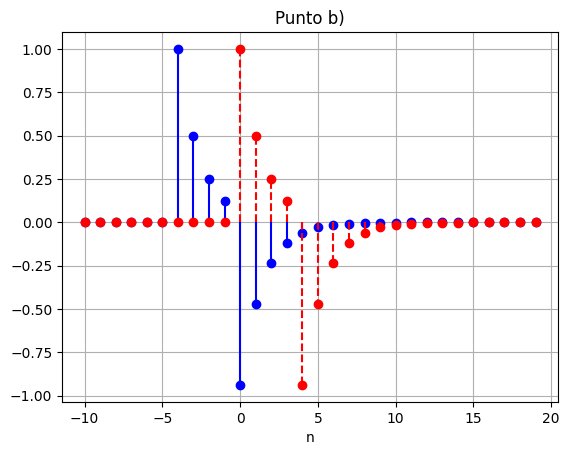

In [5]:
#%% B) x(n) =(1/2)^n * u(n)

# Escalón unitario
u = (n >= 0).astype(int)

x = (0.5)**n * u

# Convolución
y = sig.convolve(x, h, mode='same')

# Teórico
x_shift = np.roll(x, 4)
x_shift[n < 4] = 0   # corregir el corrimiento

y_teo = x - x_shift

# Gráfico
plt.figure()
plt.stem(n, y, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.stem(n, y_teo, linefmt='r--', markerfmt='ro', basefmt=' ')
plt.title('Punto b)')
plt.xlabel('n')
plt.grid()
plt.show() 

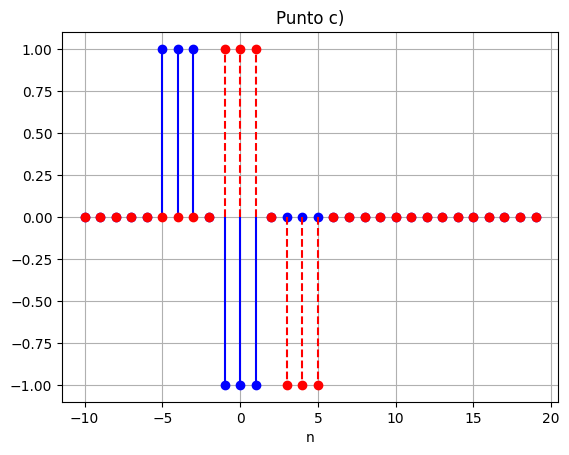

In [6]:
#%% C) x(n) = u(n+1) - u(n-2)

u1 = (n >= -1).astype(int)
u2 = (n >= 2).astype(int)

x = u1 - u2

# Convolución
y = sig.convolve(x, h, mode='same')

# Teórico
x_shift = np.roll(x, 4)
y_teo = x - x_shift

# Gráfico
plt.figure()
plt.stem(n, y, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.stem(n, y_teo, linefmt='r--', markerfmt='ro', basefmt=' ')
plt.title('Punto c)')
plt.xlabel('n')
plt.grid()
plt.show()

## Conclusión

En esta práctica se analizó la convolución de distintas señales con un sistema definido por su respuesta al impulso.

Se observó que el sistema actúa como un operador de diferencia entre la señal original y una versión retardada, lo que permite interpretarlo como un filtro discreto.

La validación numérica mediante Python permitió confirmar los resultados analíticos y facilitó la visualización del efecto de la convolución en cada caso.

Esto ayudó a consolidar la interpretación de la convolución como una operación fundamental en el análisis de sistemas discretos.